Stochastic Variational Bayes
=======================

This notebook implements Example 1 from the FMRIB tutorial on Variational Bayes II: Stochastic Variational Bayes ("fitting a Gaussian distribution).

We assume we have data drawn from a Gaussian distribution with true mean $\mu$ and true precision $\beta$:

$$
P(y_n | \mu, \beta) = \frac{\sqrt{\beta}}{\sqrt{2\pi}} \exp{-\frac{\beta}{2} (y_n - \mu)^2}
$$

One interpretation of this is that our data consists of repeated measurements of a fixed value ($\mu$) combined with Gaussian noise with standard deviation $\frac{1}{\sqrt{\beta}}$.

Here's how we can generate some sample data from this model in Python:

In [11]:
import numpy as np
from matplotlib import pyplot as plt
import torch
from tqdm.notebook import tqdm_notebook

%matplotlib inline

# Ground truth parameters
# We infer the precision, BETA, but it is useful to
# derive the variance and standard deviation from it
MU_TRUTH = 42
BETA_TRUTH = 1.0
VAR_TRUTH = 1/BETA_TRUTH
STD_TRUTH = np.sqrt(VAR_TRUTH)

# Observed data samples are generated by Numpy from the ground truth
# Gaussian distribution. Reducing the number of samples should make
# the inference less 'confident' - i.e. the output variances for
# MU and BETA will increase
N = 100
DATA = np.random.normal(MU_TRUTH, STD_TRUTH, [N])
print("Data samples are:")
print(DATA)

Data samples are:
[41.90387918 42.39738087 42.30966879 44.66315817 42.01940188 43.0616913
 43.41420699 42.68634181 42.48905198 41.35285856 42.40742563 40.96495357
 40.78482913 41.35916536 40.76061577 42.56574458 43.3780424  41.93561418
 43.58000042 42.91411822 42.35802929 42.62664505 43.11990191 42.52855695
 42.94713655 40.81981141 42.36085208 40.96012045 42.59251302 41.51962067
 41.25813519 41.77133768 42.13161225 41.07391003 41.55230599 41.8846635
 41.07473869 41.71926774 41.6945459  41.60084556 41.49608755 41.5521488
 41.47915645 41.59831787 42.54253249 41.91930124 41.68075408 41.74161877
 42.28621661 43.28368612 42.49690041 41.98277002 39.78272222 41.02979972
 40.56419491 42.04901858 41.73998798 44.65780793 43.03977305 41.35889928
 41.11846276 40.22468672 41.81724804 42.08854448 43.15842599 42.34083098
 41.56095905 41.10459217 42.21747824 41.81313287 43.5042896  43.91745714
 41.62625961 41.76791261 40.97014946 41.06083872 41.81219809 39.60547198
 41.36707123 42.86661192 42.04487575

In the 'signal + noise' interpretation we can view this as noisy measurements (red crosses) of a constant signal (green line):

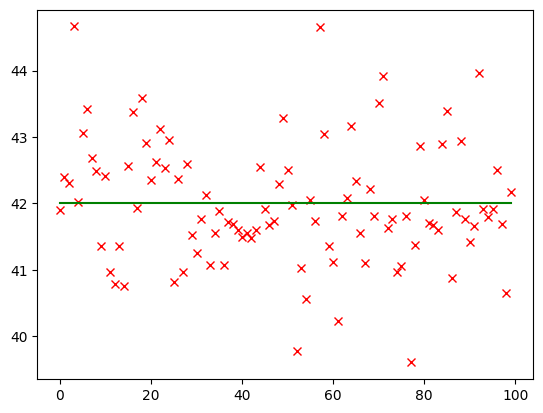

In [12]:
plt.figure()
plt.plot(DATA, "rx")
plt.plot([MU_TRUTH] * N, "g")
plt.show()

In [13]:
m0 = 0.0
v0 = 10000.0
b0 = 0.0
w0 = 10000.0
print("Priors: P(mu, log(1/beta)) = MVN([%f, %f], [[%f, 0], [0, %f]])" % (m0, v0, b0, w0))

Priors: P(mu, log(1/beta)) = MVN([0.000000, 10000.000000], [[0.000000, 0], [0, 10000.000000]])


As with analytic Variational Bayes, we need to choose an approximate form for our priors and posteriors. However we have more freedom in the stochastic method since we are not limited by the requirement that the distributions be conjugate with respect to the likelihood. 

We will choose a multivariate normal distribution (MVN) over the two parameters $\mu$ and $log(\frac{1}{\beta})$ for prior and posterior. Inferring the log of the noise variance is useful as it avoid the possibility of negative values during the optimization which would make the likelihood ill-defined.

The choice of an MVN means that we can allow for covariance (correlation) between the noise and signal parameters. This is unlike the analytic case where the posterior had to be factorised over these two parameters.

An MVN distribution for $N$ parameters is defined by a vector of $N$ mean values and an $N \times N$ covariance matrix. For the prior we will use the following values:

$$\textbf{m}_0 = \begin{bmatrix} \mu_0 \\ b_0 \end{bmatrix}$$

$$\textbf{C}_0 = \begin{bmatrix} v_0 & 0 \\ 0 & w_0 \end{bmatrix}$$

Note that we are not assuming any prior covariance. 

We define some suitable relatively uninformative prior values here:

Stochastic VB is based around minimising the free energy so we will need to implement the calculation of the free energy. We will be using the PyTorch framework to perform the minimisation so the calculation must be in terms of tensors (multidimensional arrays). In our case the following constant tensors must be defined (where $N$ is the number of data values we have:

 - Data samples: $[N]$
 - Prior mean: $[2]$
 - Prior covariance: $[2 \times 2]$

We must also define *variable* tensors for the posterior - PyTorch will allow these to change during the optimization in order to minimise the cost (free energy):

 - Posterior mean: $[2]$
 - Posterior covariance: $[2 \times 2]$

The posterior covariance must be a positive-definite matrix - since the optimizer does not know this, it is possible that invalid values may arise and the optimization will fail. To get around this restriction we build the covariance matrix from its Chlolesky decomposition.

$$\textbf{C} = (\textbf{C}_{chol})^T\textbf{C}_{chol}$$

$\textbf{C}_{chol}$ must have positive diagonal elements, so we define the underlying variables for these elements in terms of the log and then form the full $\textbf{C}_{chol}$ matrix as a sum of the exponentials of the log-diagonal elements, and independent variables for the off-diagonal components.

The code for this is below. Note that we need to define initial values for the posterior variables. It turns out that in the stochastic method it is important that the initial poster variance is not too large so although the prior is not informative, the initial posterior is. 

The next requirement is to be able to obtain a sample of *predicted* data values from the posterior. In stochastic VB this is used to approximate the integrals in the calculation of the free energy. It is *not* related to the number of data samples we have. Smaller values give quicker calculation, but may result in a noisy, non-convergent optimization. We'll start off with a sample size of 5, but you can change this later if you want.

Note the use of the 'reparameterization trick' to express the samples as the scaling of a fixed MVN distribution - this improves the ability of the optimizer to choose better values for the next iteration.

Next we need to implement the free energy calculation. This is the sum of the reconstruction loss (the extent to which the posterior matches the data) and the latent loss (the extent to which the posterior matches the prior). Let's do the reconstruction loss first which is the expected value of the log-likelihood across the posterior distribution. Remember that the expectation integral is being approximated using the samples we have from the posterior. So we evaluate the log-likelihood for *each* set of samples and then take the mean across all the samples.

On to the latent loss, this is the log-KL divergence between the posterior and prior. Since
both our prior and posterior are MVN distributions, we can use a known analytic result as
given in the tutorial:

$\log P(y|\mu,\beta)=\frac n2\log\left(\frac{\beta}{2\pi}\right)-\frac{\beta}2\sum(y_i-\mu)^2$, log-KL=$\frac12\left(Tr(C_0^{-1}C)-\log\left(\frac{|C|}{|C_0|}\right)-N+(m-m_0)^TC_0^{-1}(m-m_0)\right)$


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

data = torch.tensor(DATA, dtype=dtype, device=device)     
prior_means = torch.tensor([m0, v0], dtype=dtype, device=device)      
prior_covariance = torch.tensor([[v0, 0.0], [0.0, w0]], dtype=dtype, device=device) 

# Trainable variational params
chol_off_diag = torch.nn.Parameter(torch.tensor([[0.0, 0.0],
                                                 [0.0, 0.0]], dtype=dtype, device=device))

post_means_init = torch.tensor([0.0, 0.0], dtype=dtype, device=device)
post_covariance_init = torch.tensor([[1.0, 0.0],
                                     [0.0, 1.0]], dtype=dtype, device=device)

chol_log_diag = torch.nn.Parameter(torch.log(torch.diag(post_covariance_init)))  
post_means = torch.nn.Parameter(post_means_init)                                 


def cost_fun():
    N = 100  # number of observations
    S = 5    # number of samples from posterior

    tril_off = torch.tril(chol_off_diag)

    # chol_diag = diag(sqrt(exp(chol_log_diag)))
    chol_diag = torch.diag(torch.sqrt(torch.exp(chol_log_diag)))

    # L = chol_diag + lower-triangular(offdiag)
    post_covariance_chol = chol_diag + tril_off

    # C = L^T L
    post_covariance = post_covariance_chol.T @ post_covariance_chol

    # eps ~ N(0, I)
    eps = torch.randn((2, S), dtype=dtype, device=device)

    samples = post_means.view(2, 1).expand(2, S)

    # post_samples = samples + L @ eps
    post_samples = samples + (post_covariance_chol @ eps)

    mu_samples = post_samples[0]

    log_noise_var = -post_samples[1] 
    noise_var = torch.exp(log_noise_var)

    prediction = mu_samples.view(S, 1).expand(S, N)

    data_ = data
    if data_.ndim == 1:
        data_ = data_.view(1, -1).expand(S, N)

    sum_square_diff = torch.sum((data_ - prediction) ** 2, dim=-1)

    log_likelihood = 0.5 * (
        -log_noise_var * torch.tensor(float(N), dtype=dtype, device=device)
        - (sum_square_diff / noise_var)
    )

    reconstr_loss = -torch.mean(log_likelihood)

    #KLfor Gaussians
    C = post_covariance
    C0 = prior_covariance
    C0_inv = torch.linalg.inv(C0)

    dm = (post_means - prior_means)
    m_minus_m0 = dm.view(-1, 1)      # [2,1]
    m_minus_m0_T = dm.view(1, -1)    # [1,2]

    term1 = torch.trace(C0_inv @ C)

    signC, logdetC = torch.linalg.slogdet(C)
    signC0, logdetC0 = torch.linalg.slogdet(C0)
    term2 = -(logdetC - logdetC0)

    term3 = -2.0
    term4 = (m_minus_m0_T @ C0_inv @ m_minus_m0).squeeze()  # scalar

    latent_loss = 0.5 * (term1 + term2 + term3 + term4)

    cost = reconstr_loss + latent_loss
    return cost

To optimize the posterior we need to iteratively minimise the cost using PyTorch's built in gradient optimizer. We use the Adam optimizer for this, which is a refinement of the standard Gradient Descent optimizer. 

In [15]:
optimizer = torch.optim.Adam([post_means, chol_log_diag, chol_off_diag], lr=0.5)

cost_history = []
for epoch in tqdm_notebook(range(4000), desc="Epoch:"):
    optimizer.zero_grad()
    loss = cost_fun()
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(epoch, float(loss.detach().cpu()))
    cost_history.append(loss.detach().cpu().numpy())

Epoch::   0%|          | 0/4000 [00:00<?, ?it/s]

0 33495.5390625
500 5446.22998046875
1000 5416.20263671875
1500 5405.6708984375
2000 5392.701171875
2500 5346.22705078125
3000 5329.90185546875
3500 5077.6904296875


We should find our estimates for mu and beta are as expected, remembering that we chose
to estimate $-\log{\beta}$:

In [16]:
final_means = post_means
chol_diag = torch.diag(torch.sqrt(torch.exp(chol_log_diag)))
post_covariance_chol = chol_diag + torch.tril(chol_off_diag)
post_covariance = post_covariance_chol.T @ post_covariance_chol
final_covariance = post_covariance
print("Estimate for mu: %f (variance: %f)" % (final_means[0], final_covariance[0, 0]))
print("Estimate for beta: %f" % torch.exp(final_means[1]))

Estimate for mu: 41.969505 (variance: 0.004892)
Estimate for beta: 1.193099


The convergence of the minimisation in this case is rather slow - considering the simplicity of the problem. This is partly due to the large difference between the initial posterior and the true value for $\mu$. If we plot the cost history we can see that it gets stuck in a local minimum for some time:

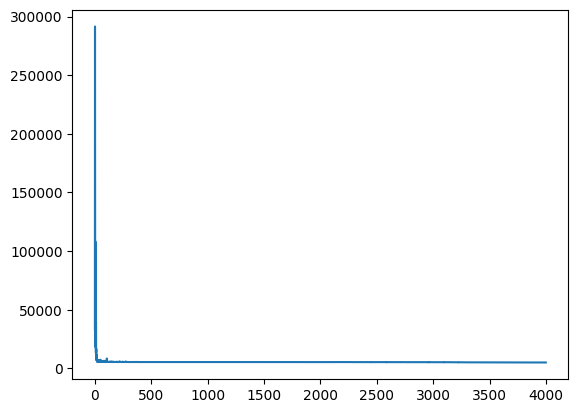

In [17]:
plt.figure()
plt.plot(cost_history)
#plt.ylim(50000, 51000)
plt.show()

We can also plot our inferred value of $\mu$ with error bars $\pm 2\sigma$ derived from the inferred variance on this parameter

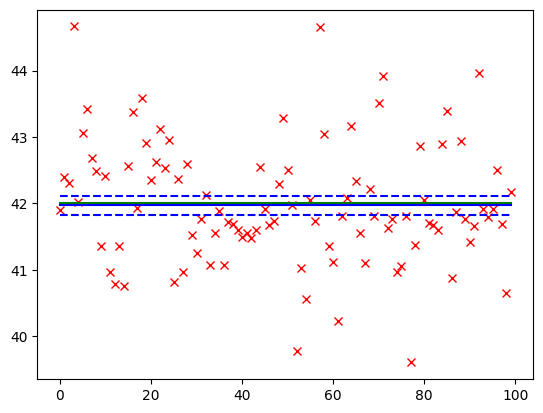

In [18]:
plt.figure()
plt.plot(DATA, "rx")
plt.plot([MU_TRUTH] * N, "g")
plt.plot([final_means[0].detach().cpu().numpy()] * N, "b")
plt.plot([final_means[0].detach().cpu().numpy()+2*np.sqrt(final_covariance[0, 0].detach().cpu().numpy())] * N, "b--")
plt.plot([final_means[0].detach().cpu().numpy()-2*np.sqrt(final_covariance[0, 0].detach().cpu().numpy())] * N, "b--")
plt.show()

The main advantage of the SVB approach is the flexibility - as well as losing the restriction to conjugate priors, it is also much easier to implement more advanced types of parameters and priors, for example global parameters or spatial regularization priors. While these can (and have been) incorporated into the analytic VB framework, they require update equations to be re-derived whereas the SVB method simply needs an expression for the cost which is generally more straightforward.

Some things you might like to try with this example:

 - Do not infer the covariance between the parameters (see commented out code in the definition of the posterior). This generally makes the convergence less noisy.
 - Modify the number of samples and the learning rate and see how they affect the convergence
 - Try implementing the stochastic form of the latent loss rather than the analytic result for an MVN that we have used here (see Box 1 in the tutorial). This is necessary in cases where we do not assume an MVN structure for the prior and posterior. Essentially you need to calculate the log PDF for the prior and posterior for each sample and take the mean over all the samples.
 
